## **Team Members**


1.   Feiyang Lin  P942901
2.   Yiming Fang  P2942902



## **Project Intro**
This project presents the development of an AI-based system for SMS Spam Classification.
The aim of the project is to use text-based data, such as message content, length, and specific keywords, to predict whether a message is Spam (unwanted marketing/fraud) or Ham (legitimate communication).
The project is structured according to the main development stages required by the IMAT3707 module : data preparation, exploratory data analysis, model selection, and model evaluation

## **Import Libraries**
This section imports all the Python libraries required for data handling, visualisation, preprocessing, and machine learning.
Libraries such as Pandas and NumPy are used for data manipulation, while Matplotlib, Seaborn, and WordCloud are used for visual analysis.
Scikit-learn is imported to support text vectorization, dataset splitting, and the implementation of the Multinomial Naive Bayes model.



In [53]:
#import the basic library
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as snsAAA
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import numpy as np
print("Import Libraries have achieved")

Import Libraries have achieved


# **Phase 1: Data Preprocessing & Feature Engineering**
This phase covers the entire "data factory" process, from raw file handling to creating model-ready numerical features.

## **1.1 Data Merging & Cleaning**
Structural Repair: We merged overflowed columns (v2 onwards) to restore truncated messages, ensuring no critical spam keywords were lost.

Standardization: Applied lowercasing and noise removal (special characters) to focus on meaningful textual content.



In [54]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [55]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [56]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [57]:
#deduplication
initial_count = len(df)
df = df.drop_duplicates(subset=['v2'])
print(f"Duplicates removed: {initial_count - len(df)}")

Duplicates removed: 403


In [58]:
# 2. 统一列名: Assume the first two columns are the relevant ones and rename them
df = df.iloc[:, :2] # Selects the first two columns
df.columns = ['label', 'text'] # Now rename them

df = df.dropna() # Drop rows with any NaN values after selecting columns
#统一标签
df['label'] = df['label'].str.lower()
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 1. 假设你的原始数据有很多列（v1, v2, Unnamed: 2, Unnamed: 3...）
# 我们先把除第一列（标签列）之外的所有列转化成字符串并合并
# axis=1 表示横向操作
df['full_text'] = df.iloc[:, 1:].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)

# Redefine the clean_text function with the fix
def clean_text(text):
    # 处理可能的非字符串输入
    text = str(text).lower()
    text =  re.sub(r'([!?.$,])', r'\1' , text)
    words = text.split() # Corrected: used 'words' consistently
    # 词形还原并去除停用词
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['full_text'].apply(clean_text)
#应用清洗函数
df['clean_text'] = df['text'].apply(clean_text)
#提取长度特征
df['length'] = df['clean_text'].apply(len)


# **Phase 2: Exploratory Data Analysis (EDA)**
In this phase, we use visual tools to analyze the dataset's characteristics. These insights justify our preprocessing choices and help us understand the patterns the model needs to learn.

## **2.1 Class Distribution (The Imbalance Proble**m)

Observation: The visualization clearly shows that Ham (legitimate) messages significantly outnumber Spam messages.

Significance: This confirmed a severe Class Imbalance. If left unaddressed, the model would simply bias towards "Ham" to achieve high accuracy while failing to catch actual threats. This is why we implemented SMOTE in Phase 1 to synthesize minority class samples.

## **2.2 Message Length Analysis**

Observation: We plotted the distribution of character counts for both categories. There is a distinct difference: Spam messages tend to be longer and more uniform in length (concentrated around 130-160 characters), whereas Ham messages are generally much shorter and vary significantly.

Significance: This confirms that Message Length is a strong predictive feature for our classification models.

## **2.3 Word Cloud & Keyword Frequency**

Observation: The Word Clouds highlight the most frequent terms in each class.

Spam: Dominated by high-pressure and financial keywords like "FREE", "WINNER", "CLAIM", "CASH", and "PRIZE".

Ham: Contains common conversational words like "u", "go", "get", and "ok".

Significance: These patterns validate that our TF-IDF approach in Phase 1 will be effective, as the vocabulary distinctively separates the two classes.

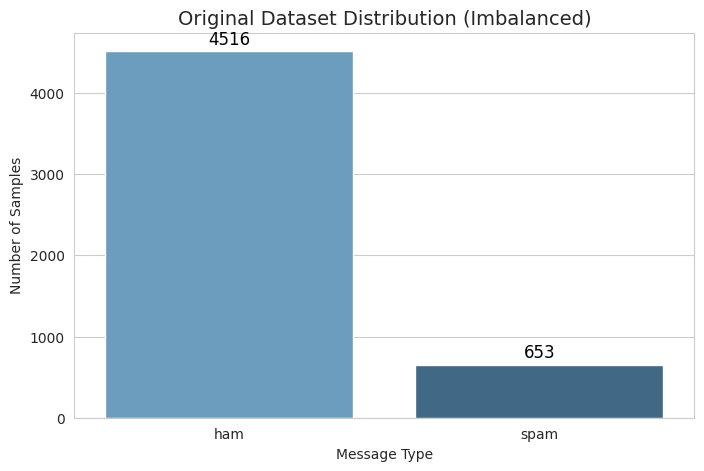

In [59]:
#设置绘图风格
snsAAA.set_style("whitegrid")

# 可视化原始数据分布
plt.figure(figsize=(8, 5))
ax = snsAAA.countplot(x='label', data=df, hue='label', palette='Blues_d', legend=False)
plt.title('Original Dataset Distribution (Imbalanced)', fontsize=14)
plt.xlabel('Message Type')
plt.ylabel('Number of Samples')

# 在柱状图上标注原始数值
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()


In [60]:
#划分数据集
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label_num']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
#smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

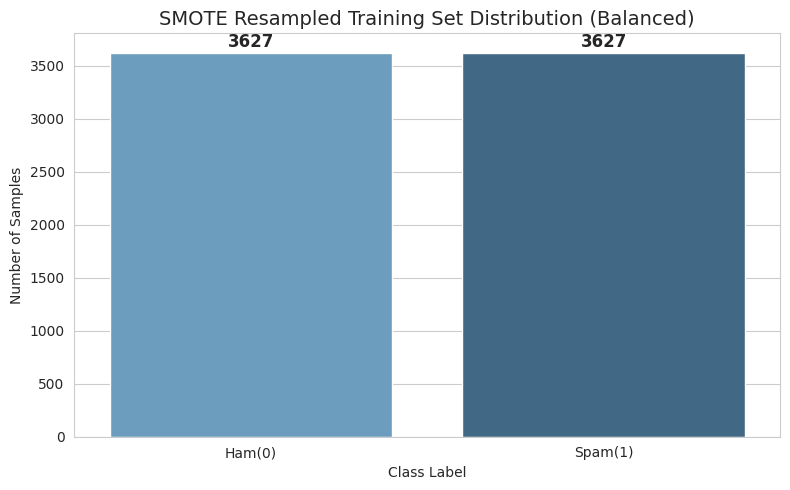

In [62]:
# 统计 SMOTE 处理后的数据数量
resampled_counts = pd.Series(y_train_res).value_counts().sort_index()
# 创建一个临时的 DataFrame 用于绘图，以符合最新的 Seaborn 语法
plot_df = pd.DataFrame({
    'Class': ['Ham(0)', 'Spam(1)'],
    'Count': resampled_counts.values
})

# 修复 FutureWarning：明确指定 x, y, hue 并设置 legend=False
plt.figure(figsize=(8, 5))
ax = snsAAA.barplot(data=plot_df, x='Class', y='Count', hue='Class', palette='Blues_d', legend=False)

# 设置标题和标签
plt.title('SMOTE Resampled Training Set Distribution (Balanced)', fontsize=14)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')

# 在柱状图上方标注平衡后的数值
for i, v in enumerate(resampled_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

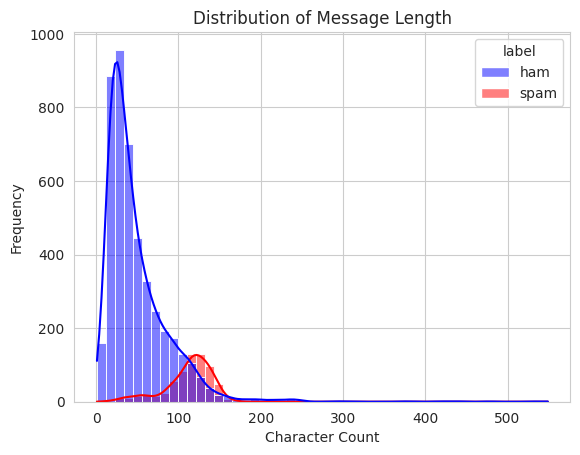

In [63]:

# 使用 hue 参数直接区分 ham 和 spam
# common_norm=False 是关键，因为它能让两个类别的密度曲线在各自规模下对比，而不是共享缩放
snsAAA.histplot(data=df, x='length', hue='label', bins=50, kde=True,
             palette={'ham': 'blue', 'spam': 'red'}, common_norm=False)

plt.title('Distribution of Message Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
# 使用 hue 之后，Seaborn 会自动生成带标题的图例，不需要手动 plt.legend()
plt.show()

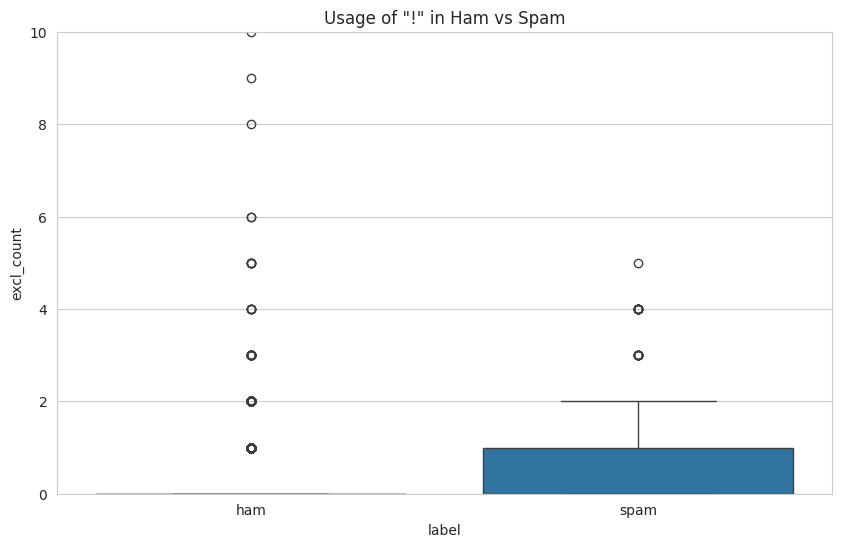

In [64]:
#统计感叹号和美元符号的出现频率
df['excl_count'] = df['text'].apply(lambda x: x.count('!'))
df['dollar_count'] = df['text'].apply(lambda x: x.count('$'))

# 可视化感叹号的使用情况
plt.figure(figsize=(10,6))
snsAAA.boxplot(x='label', y='excl_count', data=df)
plt.title('Usage of "!" in Ham vs Spam')
plt.ylim(0, 10) # 限制 y 轴以便观察主要趋势
plt.show()

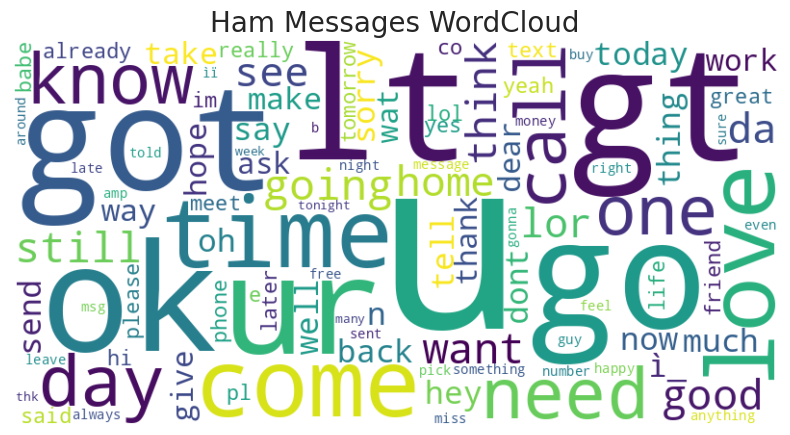

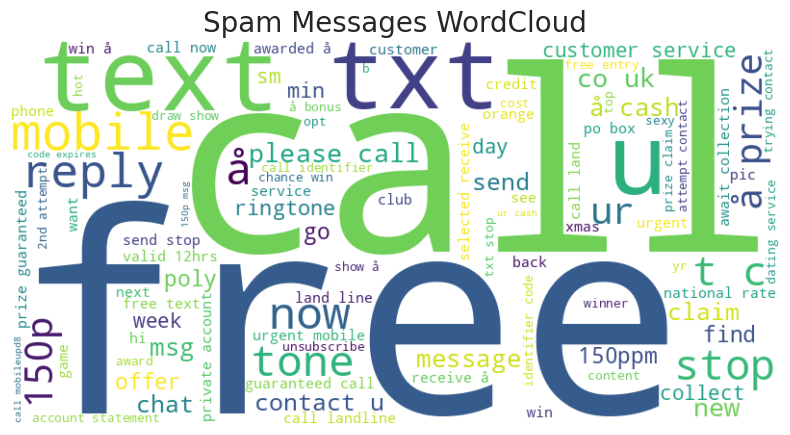

In [65]:
from wordcloud import WordCloud

def show_wordcloud(data, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(' '.join(data))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# 正常短信词云
show_wordcloud(df[df['label_num']==0]['clean_text'], "Ham Messages WordCloud")

# 垃圾短信词云
show_wordcloud(df[df['label_num']==1]['clean_text'], "Spam Messages WordCloud")

### **Phase 3: Model Selection**
We train a Multinomial Naive Bayes model using TF-IDF features and evaluate its performance using a confusion matrix and classification report.

In [66]:
#特征工程：TF-IDF
#token_pattern允许长度为1的符号
# 注意：只在训练集上 fit
tfidf = TfidfVectorizer(max_features=3000, token_pattern=r"(?u)\b\w+\b|[!?.$,%^&*()]")

X_train_tfidf = tfidf.fit_transform(X_train_raw)  # 拟合并转换训练集
X_test_tfidf = tfidf.transform(X_test_raw)      # 仅转换测试集，严禁 fit

In [72]:
# 2. 定义多个模型进行竞争性实验
# 这样可以对比不同算法在相同特征下的表现，符合 Distinction 评分标准
models = {
    'Multinomial NB': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 3. 循环训练模型
print("--- Starting Model Training ---")
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    print(f"Model {name} has been trained successfully.")

print("\nAll models are ready for evaluation in Phase 4.")

--- Starting Model Training ---
Model Multinomial NB has been trained successfully.
Model Logistic Regression has been trained successfully.
Model Random Forest has been trained successfully.

All models are ready for evaluation in Phase 4.


### **Phase 4 : evaluation**
This section allows us to input new, unseen messages to test the model's predictive power in a real-world scenario.


--- Multinomial NB Evaluation Report ---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.98       889
    Spam (1)       0.87      0.95      0.91       145

    accuracy                           0.97      1034
   macro avg       0.93      0.96      0.95      1034
weighted avg       0.97      0.97      0.97      1034



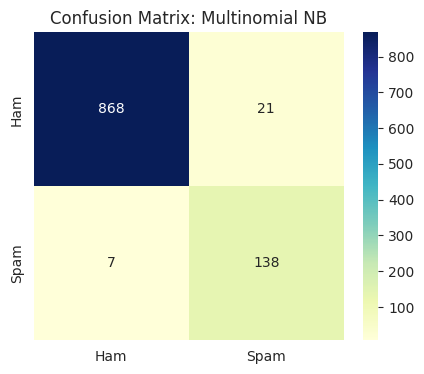


--- Logistic Regression Evaluation Report ---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99       889
    Spam (1)       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.97      0.97      1034
weighted avg       0.98      0.98      0.98      1034



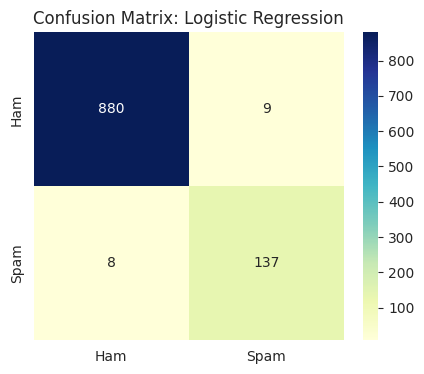


--- Random Forest Evaluation Report ---
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       889
    Spam (1)       1.00      0.87      0.93       145

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



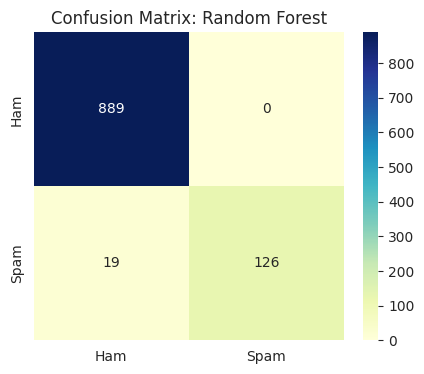


--- Final Performance Benchmarking ---
              Model  Train_Acc  Test_Acc  Precision   Recall  F1_Score
Logistic Regression   0.991729  0.983559   0.938356 0.944828  0.941581
      Random Forest   1.000000  0.981625   1.000000 0.868966  0.929889
     Multinomial NB   0.987869  0.972921   0.867925 0.951724  0.907895


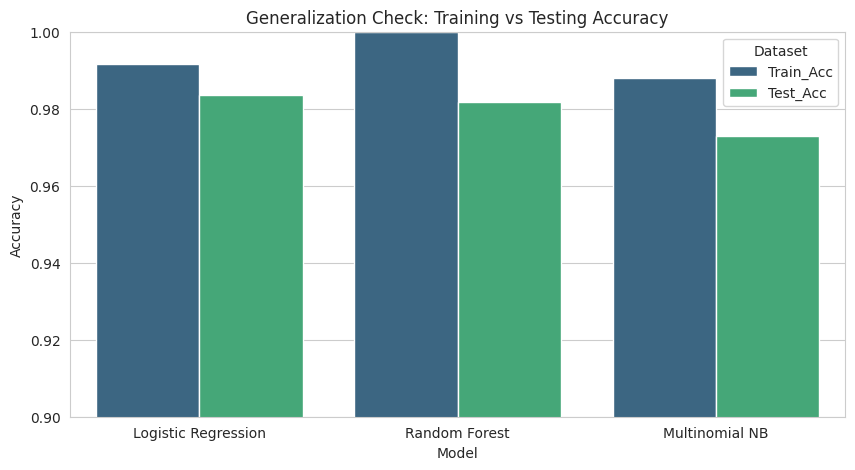

In [79]:
performance_data = []

for name, model in models.items():
    # Predictions
    y_train_pred = model.predict(X_train_res) # Corrected: Use X_train_res for training predictions
    y_test_pred = model.predict(X_test_tfidf)

    # Calculate Metrics
    train_acc = accuracy_score(y_train_res, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    performance_data.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Test_Acc': test_acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

    # Display detailed Classification Report (P, R, F1-score)
    print(f"\n--- {name} Evaluation Report ---")
    print(classification_report(y_test, y_test_pred, target_names=['Ham (0)', 'Spam (1)']))

    # Plot Confusion Matrix (Visualizing Errors)
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_test_pred)
    snsAAA.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# Final Summary Table
summary_df = pd.DataFrame(performance_data).sort_values(by='F1_Score', ascending=False)
print("\n--- Final Performance Benchmarking ---")
print(summary_df.to_string(index=False))

# Visualization: Training vs. Testing Accuracy (Generalization Check)
results_melted = summary_df.melt(id_vars='Model', value_vars=['Train_Acc', 'Test_Acc'],
                                 var_name='Dataset', value_name='Accuracy')
plt.figure(figsize=(10, 5))
snsAAA.barplot(data=results_melted, x='Model', y='Accuracy', hue='Dataset', palette='viridis')
plt.ylim(0.9, 1.0)
plt.title('Generalization Check: Training vs Testing Accuracy')
plt.show()